In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("Placement_Data_Full_Class.csv")

In [3]:
data.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [4]:
data.drop(['ssc_b','hsc_b','hsc_s','degree_t','salary'],axis=1,inplace=True)

In [5]:
data.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,91.00,58.00,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,78.33,77.48,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,68.00,64.00,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,52.00,52.00,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,73.60,73.30,No,96.8,Mkt&Fin,55.50,Placed


In [6]:
data.shape

(215, 10)

In [7]:
data.isnull().sum()

sl_no             0
gender            0
ssc_p             0
hsc_p             0
degree_p          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64

In [8]:
data['gender'].value_counts()

gender
M    139
F     76
Name: count, dtype: int64

In [9]:
data['gender'] = data.gender.map({'M':0,'F':1})
data['workex'] = data.workex.map({'No':0,'Yes':1})
data['status'] = data.status.map({'Not Placed':0,'Placed':1})
data['specialisation'] = data.specialisation.map({'Mkt&HR':0,'Mkt&Fin':1})

In [10]:
data.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,0,67.00,91.00,58.00,0,55.0,0,58.80,1
1,2,0,79.33,78.33,77.48,1,86.5,1,66.28,1
2,3,0,65.00,68.00,64.00,0,75.0,1,57.80,1
3,4,0,56.00,52.00,52.00,0,66.0,0,59.43,0
4,5,0,85.80,73.60,73.30,0,96.8,1,55.50,1


In [11]:
data['status'].value_counts()

status
1    148
0     67
Name: count, dtype: int64

In [12]:
from sklearn.utils import resample

# Separate the majority and minority classes
data_majority = data[data['status']==1]
data_minority = data[data['status']==0]


# Unsample minority class
data_minority_unsampled = resample ( data_minority,
                                     replace=True,
                                     n_samples=len(data_majority),
                                     random_state=42)

# Combine majority class with unsampled minority class
balanced_data = pd.concat([data_majority,data_minority_unsampled])

In [13]:
balanced_data['status'].value_counts()

status
1    148
0    148
Name: count, dtype: int64

In [14]:
# Seperating Features and Target
x = balanced_data.copy().drop('status',axis=1)
y = balanced_data['status']

In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)
x_train.shape , y_train.shape , x_test.shape , y_test.shape

((207, 9), (207,), (89, 9), (89,))

In [16]:
# Scale each features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# k-nearest neighbor

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

knn_y_pred = knn.predict(x_test)

accuracy_score = accuracy_score(knn_y_pred,y_test)
accuracy_score

0.8426966292134831

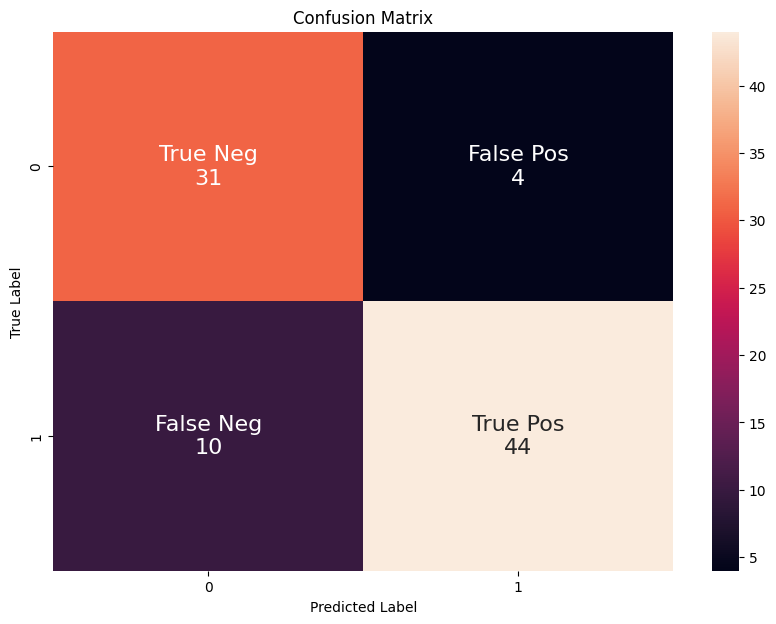

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_mat = confusion_matrix(y_test,knn_y_pred)
fig = plt.figure(figsize=(10,7))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()
decision_tree.fit(x_train,y_train)
decision_tree_y_pred = decision_tree.predict(x_test)
decision_tree_accuracy = decision_tree.score(x_test,y_test)
decision_tree_accuracy

0.8651685393258427

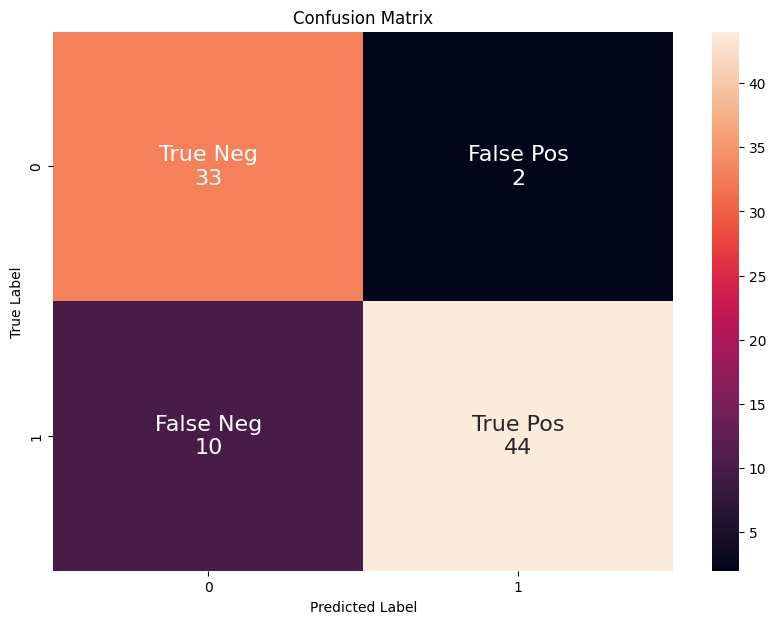

In [20]:
conf_mat = confusion_matrix(y_test, decision_tree_y_pred)
fig = plt.figure(figsize=(10,7))
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# SVM

In [21]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train,y_train)
svm_y_pred = svc.predict(x_test)
svc_accuracy = svc.score(x_test,y_test)
svc_accuracy

0.8876404494382022

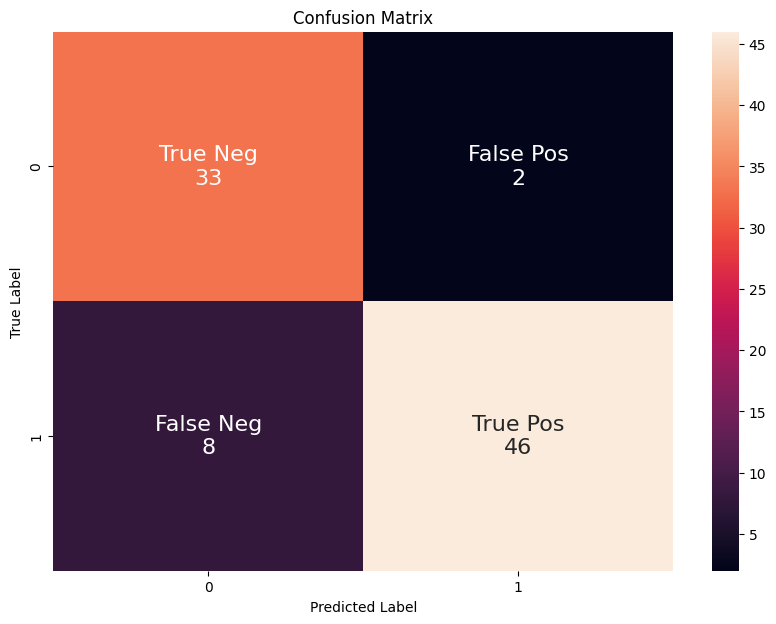

In [22]:
conf_mat = confusion_matrix(y_test, svm_y_pred)
fig = plt.figure(figsize=(10,7))
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=500,class_weight='balanced')
random_forest.fit(x_train,y_train)
random_forest_y_pred = random_forest.predict(x_test)
random_forest.score(x_train,y_train)
random_forest_accuracy = random_forest.score(x_test,y_test)
random_forest_accuracy

0.9213483146067416

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test,random_forest_y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91        35
           1       0.98      0.89      0.93        54

    accuracy                           0.92        89
   macro avg       0.91      0.93      0.92        89
weighted avg       0.93      0.92      0.92        89



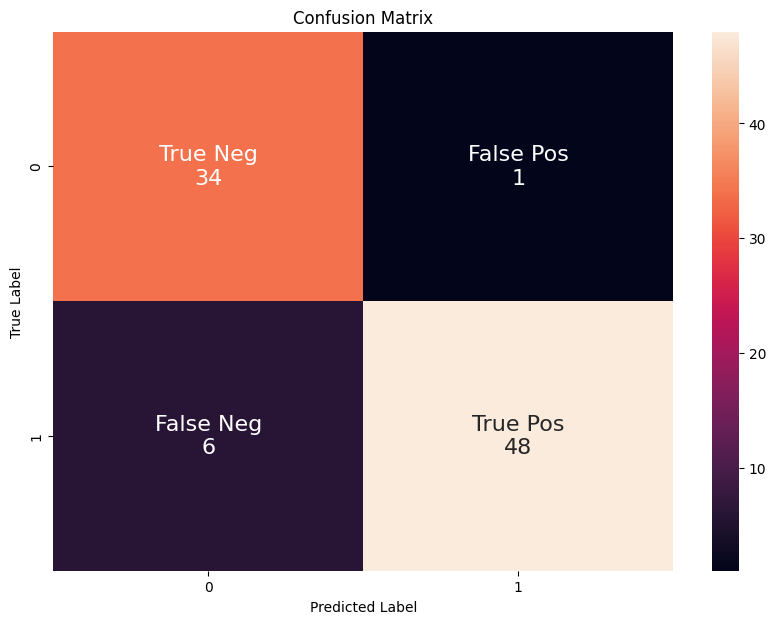

In [25]:
conf_mat = confusion_matrix(y_test, random_forest_y_pred)
fig = plt.figure(figsize=(10,7))
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Gaussian Naive Bayes

In [26]:
from sklearn.naive_bayes import GaussianNB
gaussian = GaussianNB()
gaussian.fit(x_train, y_train)
gaussian_y_pred = gaussian.predict(x_test)
gaussian_accuracy = gaussian.score(x_test, y_test)
gaussian_accuracy

0.8314606741573034

# Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(x_train, y_train)
lg_y_pred = lg.predict(x_test)
lg_accuracy = lg.score(x_test, y_test)
lg_accuracy

0.898876404494382

# Single Input Predictions

In [34]:
print("Predicted Class :",random_forest.predict(x_test[1].reshape(1,-1))[0])
print("Actual Class:", y_test.iloc[1])

Predicted Class : 1
Actual Class: 1


In [35]:
print("Predicted Class :",random_forest.predict(x_test[2].reshape(1,-1))[0])
print("Actual Class:", y_test.iloc[2])

Predicted Class : 0
Actual Class: 1


In [36]:
print("Predicted Class :",random_forest.predict(x_test[6].reshape(1,-1))[0])
print("Actual Class:", y_test.iloc[6])

Predicted Class : 1
Actual Class: 1


# Predictive system

In [31]:
def prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p):
    data = {
    'sl_no': [sl_no],
    'gender': [gender],
    'ssc_p': [ssc_p],
    'hsc_p': [hsc_p],
    'degree_p': [degree_p],
    'workex': [workex],
    'etest_p': [etest_p],
    'specialisation': [specialisation],
    'mba_p': [mba_p]
    }
    data = pd.DataFrame(data)
    data['gender'] = data['gender'].map({'M':0,"F":1})
    data['workex'] = data['workex'].map({"Yes":1,"No":0})
    data['specialisation'] = data['specialisation'].map({"Mkt&HR":0,"Mkt&Fin":1})
    scaled_df = scaler.fit_transform(data)
    result = random_forest.predict(scaled_df).reshape(1, -1)
    return result[0]

In [32]:
sl_no =11
gender = "F"
ssc_p =58.
hsc_p = 61.
degree_p = 60.
workex = "Yes"
etest_p = 62.
specialisation = "Mkt&Fin"
mba_p = 60.85

result = prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p)

if result == 1:
    print('place')

else:
    print('not place')

not place


In [33]:
import pickle 
pickle.dump(random_forest,open('model.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))